In [4]:
import sqlite3
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BASE_DIR = Path.cwd().parents[0]
GOLD_PATH = BASE_DIR / "Data" / "Gold" / "Gold.db"
QUERY_PATH = BASE_DIR / "Analysis" / "BTCxgM2.sql"


with open(QUERY_PATH, "r") as f:
    query = f.read()

con = sqlite3.connect(GOLD_PATH)

df = pd.read_sql_query(query, con=con)
df = df.sort_values(by="Month", ascending=True)

df["M2_global"] = pd.to_numeric(df["M2_global"])
df["BTC_price_M"] = pd.to_numeric(df["BTC_price_M"])
df["Month"] = pd.to_datetime(df["Month"])

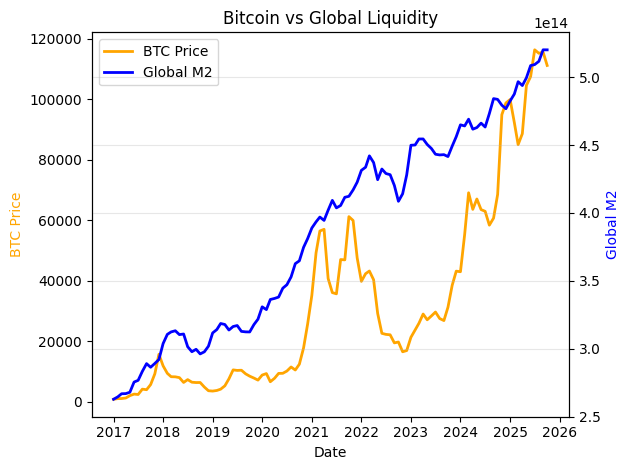

In [5]:
fig, ax1 = plt.subplots()

# Plot do BTC
line1, = ax1.plot(
    df["Month"], 
    df["BTC_price_M"], 
    color="orange", 
    linewidth=2,
    label="BTC Price"
)

ax1.set_ylabel("BTC Price", color="orange")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

#Plot do M2 global
line2, = ax2.plot(
    df["Month"], 
    df["M2_global"], 
    color="blue", 
    linewidth=2,
    label="Global M2"
)

ax2.set_ylabel("Global M2", color="blue")

# Apenas janeiro de cada ano
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# legenda 
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Bitcoin vs Global Liquidity")
plt.grid(alpha=0.3)

fig.tight_layout()
plt.show()
